<h1><center>Laboratorio 6: ¿A cuanto la casa 🏡?</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Felipe Muñoz M.
- Nombre de alumno 2: Antonia Landaeta R.


### **Link de repositorio de GitHub:** `https://github.com/FeLiJaNdRo/MDS7202-Labs`


## Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

### Objetivos principales del laboratorio

- Aplicar los conocimientos de preprocesamiento, feature extraction y regresión vistos hasta el momento
- Calcular, aplicar e interpretar métricas de regresión
- Mostrar comprensión sobre el fenómeno de sobreajuste y las implicancias que este tiene, así como formas de evitarlo


El laboratorio deberá ser desarrollado con las herramientas de scikit-learn, incluyendo el uso de pipelines

## Descripción del laboratorio.

Usted acaba de ser contratado por la gran empresa inmobiliaria chilena ***TasAi Ltda.*** Esta empresa maneja una parte importante de las propiedades de Santiago, y buscan aumentar sus ventas mediante un **modelo de pricing** que optimice el valor de venta de las propiedades. Para esto, le han encomendado la tarea de liderar un equipo multidisciplinario de analistas, científicos e ingenieros de datos para analizar datos de características de viviendas de santiago de Chile y sus precios y así poder predecir el valor de venta.

## 1. Pipeline predictivo

### 1.1 EDA [1 ptos]

Don ElIas, CEO de _Tasai_ le presenta a su equipo, los mejores **Data Engineers** de la empresa, quienes mediante técnicas avanzadas de web scrapping de sitios inmobiliarios han logrado construir una base de datos con los precios de venta de viviendas y diversas características de estas, presentes en el archivo `"Precios Casas RM.csv"`. Los data engineers confeccionaron una documentación del dataset, la cual se encuentra en el archivo [documentacion_dataset.md](.\documentacion_dataset.md)

Don ElIas le indica que desean optimizar el modelo de **pricing** de _Tasai_. Para esto, debe utilizar de los datos obtenidos por los data engineers para crear un **modelo predictivo** que permita predecir el precio de venta final de la propiedad en pesos chilenos, presentes en la columna `Price_CLP`.

Su primera tarea será explorar el dataset para entender sus variables y entender cómo procesarlas para entrenar el modelo. Para esto deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Ejecutar la función `profile_dataframe` con el dataframe
- Responder las preguntas que encontrará al final de la secciónn respecto a las distribuciones

In [ ]:
!uv add numpy pandas scikit-learn umap-learn openpyxl plotly pre-commit ruff

zsh:1: command not found: uv


In [1]:
from pandas.api.types import is_numeric_dtype  # noqa: I001
from pandas.api.types import is_datetime64_any_dtype, is_timedelta64_dtype
import plotly.express as px
import missingno as msno

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd

df = pd.read_csv("Precios Casas RM.csv")

In [3]:
import plotly.io as pio  # para que aparezcan los gráficos en el repositorio

pio.renderers.default = "png"

In [4]:
def profile_dataframe(df, n_samples=1000, random_state=42):
    display(Markdown("# Analisis columnas"))
    display(Markdown("## Descripcion variables"))
    display(df.describe())
    for col in df.columns:
        serie = df[col].copy()

        profile = pd.Series(dtype="object")
        profile["Type"] = serie.dtype
        profile = pd.concat([profile, serie.describe()])

        # profile = pd.Series([])

        if is_numeric_dtype(serie):
            profile["Negative"] = (serie < 0).sum()
            profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Zeros"] = (serie == 0).sum()
            profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
            profile["Kurt"] = serie.kurt()
            profile["Skew"] = serie.skew()

        profile[" "] = " "  # espacio

        profile["Missing cells"] = serie.isnull().sum()
        profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
        profile["Duplicate rows"] = serie.duplicated(False).sum()
        profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
        profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

        # profile = pd.concat([profile, description])

        profile = profile.rename(
            index={
                "count": "Number of observations",
                "mean": "Mean",
                "std": "Std",
                "min": "Min",
                "max": "Max",
                "unique": "Unique",
                "top": "Top",
                "freq": "Freq",
            }
        )

        if is_numeric_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}", nbins=48)

        elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
            sampled_serie = serie.sample(n_samples, random_state=random_state)
            fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

        else:
            count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
            fig = px.bar(
                x=count[serie.name].astype(str),
                y=count["Count"],
                title=f"100 Most common categories of {serie.name}",
            )
        display(Markdown(f"## {serie.name} Profile"))
        display(profile)
        fig.show()

    display(Markdown("# Analisis de nulos"))
    display(Markdown("## Nulos por columna"))
    display(df.isna().sum())
    display(Markdown("## Visualizacion de nulos"))
    msno.matrix(df)
    display(Markdown("## Correlacion de nulidad"))
    msno.heatmap(df)

# Analisis columnas

## Descripcion variables

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,7.779000e+03,7779.000000,7.779000e+03,7779.000000,7714.000000,7533.000000,7571.000000,5489.000000,7.779000e+03
mean,3.642481e+08,10234.571153,4.536091e+05,3.994087,2.653746,229.923669,807.919826,2.980506,9.910828e+06
std,3.868810e+08,10870.491584,4.817945e+05,1.622821,1.465103,1676.898812,9050.893115,17.749384,2.046317e+06
min,2.085000e+03,0.000000,3.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.213620e+06
25%,1.200000e+08,3372.000000,1.494400e+05,3.000000,2.000000,85.000000,129.500000,1.000000,8.563078e+06
50%,2.050000e+08,5760.000000,2.552930e+05,4.000000,2.000000,128.000000,210.000000,2.000000,1.054807e+07
75%,4.911420e+08,13800.000000,6.116340e+05,5.000000,3.000000,200.000000,443.000000,3.000000,1.152463e+07
max,5.516450e+09,155000.000000,6.869801e+06,27.000000,29.000000,120000.000000,678000.000000,1269.000000,1.234149e+07


## Price_CLP Profile

Type                                 int64
Number of observations              7779.0
Mean                      364248117.632086
Std                       386880986.221857
Min                                 2085.0
25%                            120000000.0
50%                            205000000.0
75%                            491142000.0
Max                           5516450000.0
Negative                                 0
Negative (%)                         0.0 %
Zeros                                    0
Zeros (%)                            0.0 %
Kurt                             14.312728
Skew                              2.800394
                                          
Missing cells                            0
Missing cells (%)                    0.0 %
Duplicate rows                        6680
Duplicate rows (%)                 85.87 %
Total size in memory           62364 bytes
dtype: object

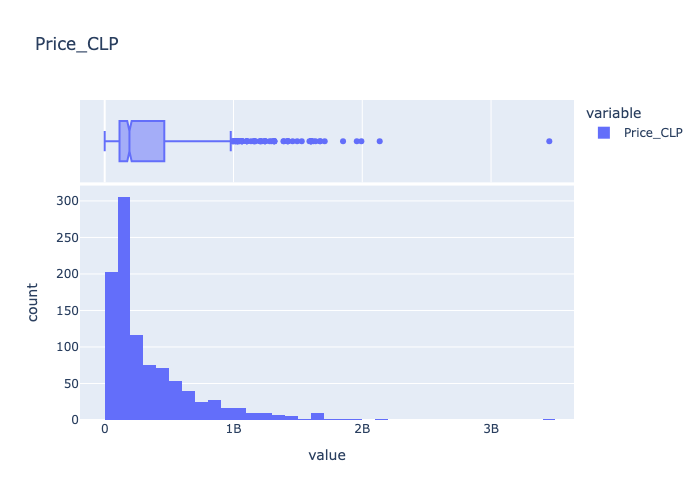

## Price_UF Profile

Type                             int64
Number of observations          7779.0
Mean                      10234.571153
Std                       10870.491584
Min                                0.0
25%                             3372.0
50%                             5760.0
75%                            13800.0
Max                           155000.0
Negative                             0
Negative (%)                     0.0 %
Zeros                               18
Zeros (%)                       0.23 %
Kurt                         14.312754
Skew                          2.800397
                                      
Missing cells                        0
Missing cells (%)                0.0 %
Duplicate rows                    6785
Duplicate rows (%)             87.22 %
Total size in memory       62364 bytes
dtype: object

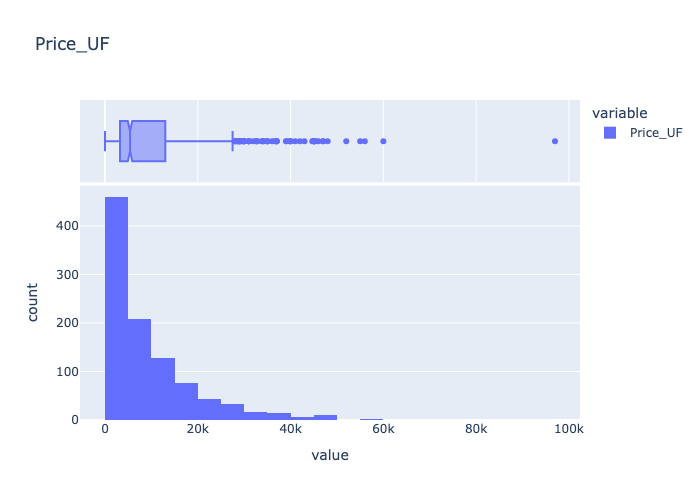

## Price_USD Profile

Type                              int64
Number of observations           7779.0
Mean                      453609.112611
Std                       481794.503961
Min                                 3.0
25%                            149440.0
50%                            255293.0
75%                            611634.0
Max                           6869801.0
Negative                              0
Negative (%)                      0.0 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                          14.312729
Skew                           2.800394
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                     6707
Duplicate rows (%)              86.22 %
Total size in memory        62364 bytes
dtype: object

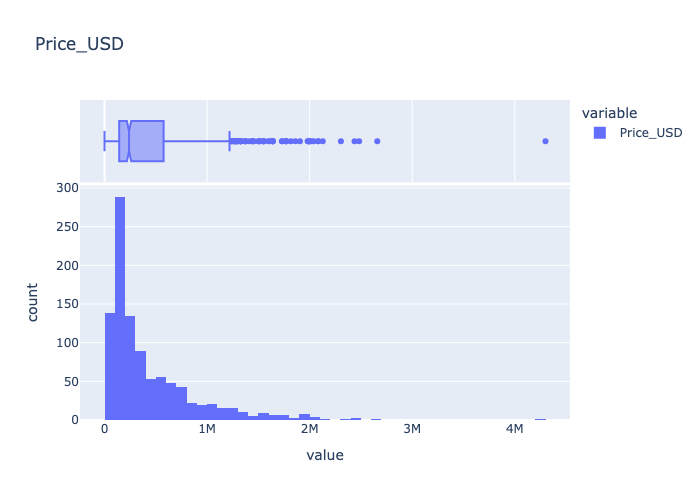

## Comuna Profile

Type                              str
Number of observations           7779
Unique                             51
Top                        PuenteAlto
Freq                              814
                                     
Missing cells                       0
Missing cells (%)               0.0 %
Duplicate rows                   7778
Duplicate rows (%)            99.99 %
Total size in memory      62364 bytes
dtype: object

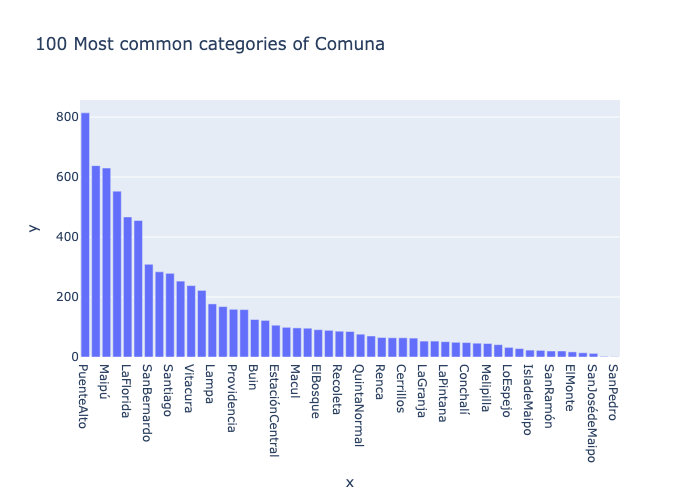

## Ubicacion Profile

Type                              str
Number of observations           7779
Unique                           6620
Top                             Maipú
Freq                               45
                                     
Missing cells                       0
Missing cells (%)               0.0 %
Duplicate rows                   1758
Duplicate rows (%)             22.6 %
Total size in memory      62364 bytes
dtype: object

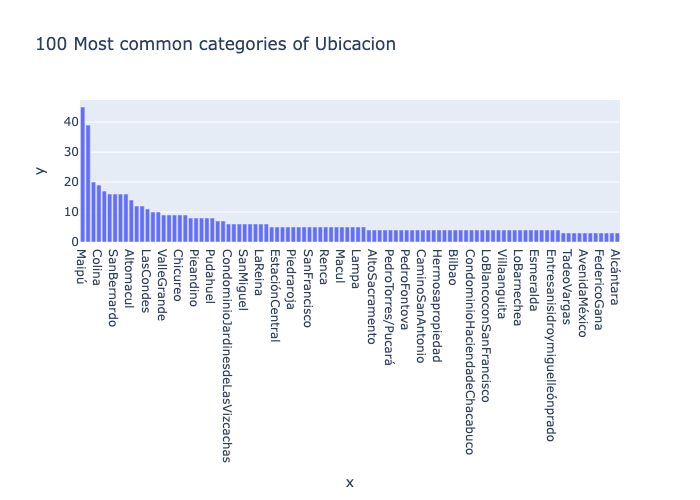

## Dorms Profile

Type                            int64
Number of observations         7779.0
Mean                         3.994087
Std                          1.622821
Min                               1.0
25%                               3.0
50%                               4.0
75%                               5.0
Max                              27.0
Negative                            0
Negative (%)                    0.0 %
Zeros                               0
Zeros (%)                       0.0 %
Kurt                        23.312355
Skew                         3.023193
                                     
Missing cells                       0
Missing cells (%)               0.0 %
Duplicate rows                   7775
Duplicate rows (%)            99.95 %
Total size in memory      62364 bytes
dtype: object

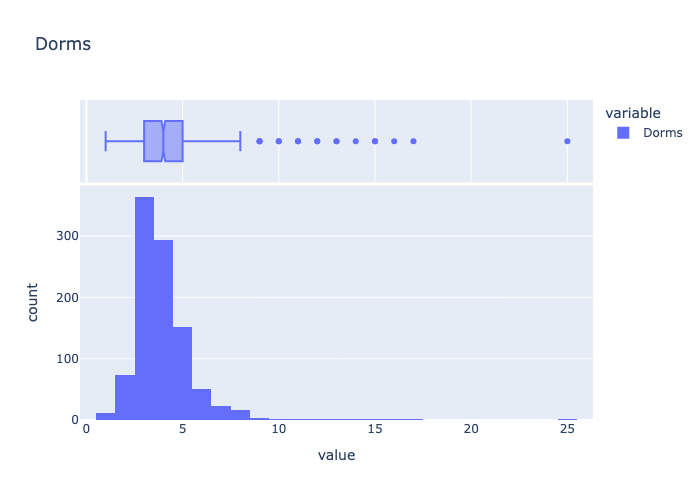

## Baths Profile

Type                          float64
Number of observations         7714.0
Mean                         2.653746
Std                          1.465103
Min                               1.0
25%                               2.0
50%                               2.0
75%                               3.0
Max                              29.0
Negative                            0
Negative (%)                    0.0 %
Zeros                               0
Zeros (%)                       0.0 %
Kurt                        20.753874
Skew                         2.255617
                                     
Missing cells                      65
Missing cells (%)              0.84 %
Duplicate rows                   7776
Duplicate rows (%)            99.96 %
Total size in memory      62364 bytes
dtype: object

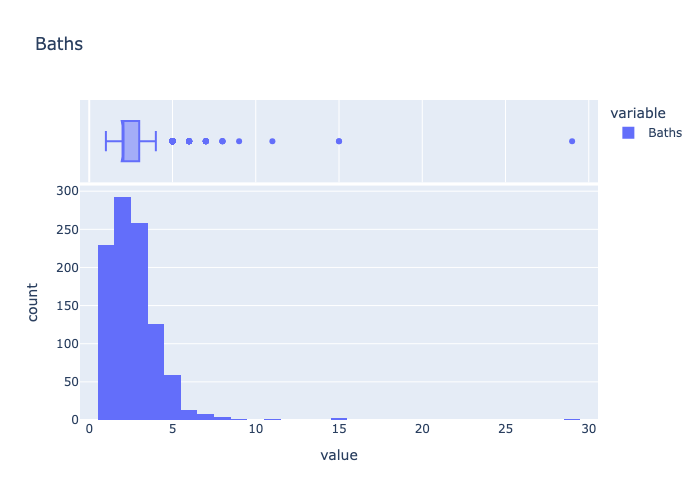

## Built Area Profile

Type                          float64
Number of observations         7533.0
Mean                       229.923669
Std                       1676.898812
Min                               1.0
25%                              85.0
50%                             128.0
75%                             200.0
Max                          120000.0
Negative                            0
Negative (%)                    0.0 %
Zeros                               0
Zeros (%)                       0.0 %
Kurt                       3692.38355
Skew                        55.995677
                                     
Missing cells                     246
Missing cells (%)              3.16 %
Duplicate rows                   7620
Duplicate rows (%)            97.96 %
Total size in memory      62364 bytes
dtype: object

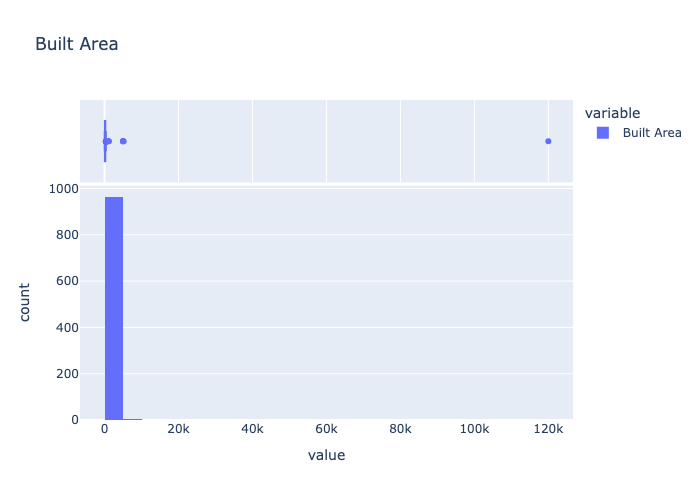

## Total Area Profile

Type                          float64
Number of observations         7571.0
Mean                       807.919826
Std                       9050.893115
Min                               1.0
25%                             129.5
50%                             210.0
75%                             443.0
Max                          678000.0
Negative                            0
Negative (%)                    0.0 %
Zeros                               0
Zeros (%)                       0.0 %
Kurt                      4314.082427
Skew                        61.265972
                                     
Missing cells                     208
Missing cells (%)              2.67 %
Duplicate rows                   7352
Duplicate rows (%)            94.51 %
Total size in memory      62364 bytes
dtype: object

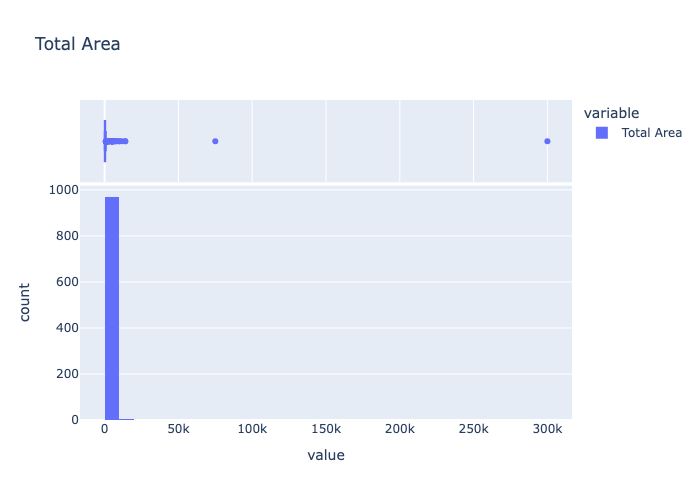

## Parking Profile

Type                          float64
Number of observations         5489.0
Mean                         2.980506
Std                         17.749384
Min                               1.0
25%                               1.0
50%                               2.0
75%                               3.0
Max                            1269.0
Negative                            0
Negative (%)                    0.0 %
Zeros                               0
Zeros (%)                       0.0 %
Kurt                      4734.326017
Skew                        67.077539
                                     
Missing cells                    2290
Missing cells (%)             29.44 %
Duplicate rows                   7775
Duplicate rows (%)            99.95 %
Total size in memory      62364 bytes
dtype: object

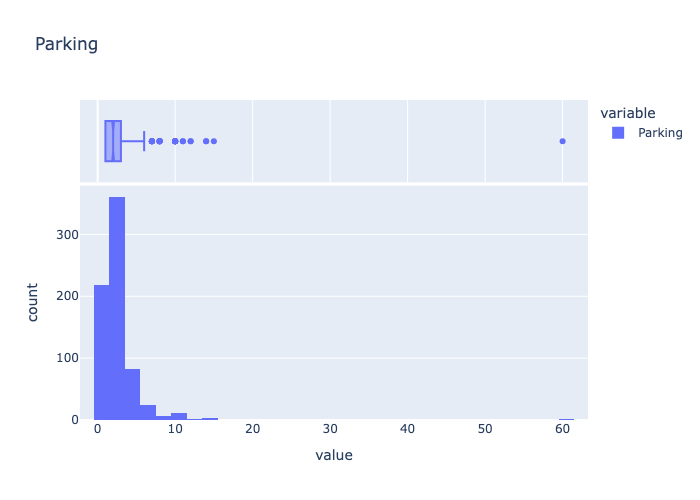

## id Profile

Type                               int64
Number of observations            7779.0
Mean                      9910827.694048
Std                       2046316.666963
Min                            1213620.0
25%                            8563078.5
50%                           10548072.0
75%                           11524632.0
Max                           12341490.0
Negative                               0
Negative (%)                       0.0 %
Zeros                                  0
Zeros (%)                          0.0 %
Kurt                            0.198296
Skew                           -0.935604
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                         2
Duplicate rows (%)                0.03 %
Total size in memory         62364 bytes
dtype: object

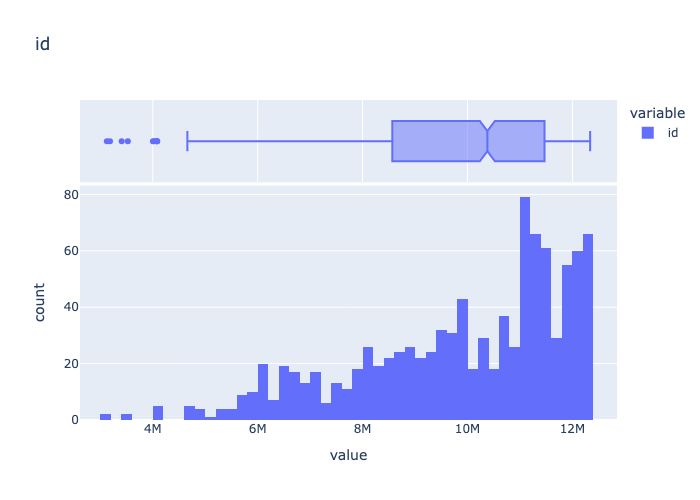

# Analisis de nulos

## Nulos por columna

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
dtype: int64

## Visualizacion de nulos

## Correlacion de nulidad

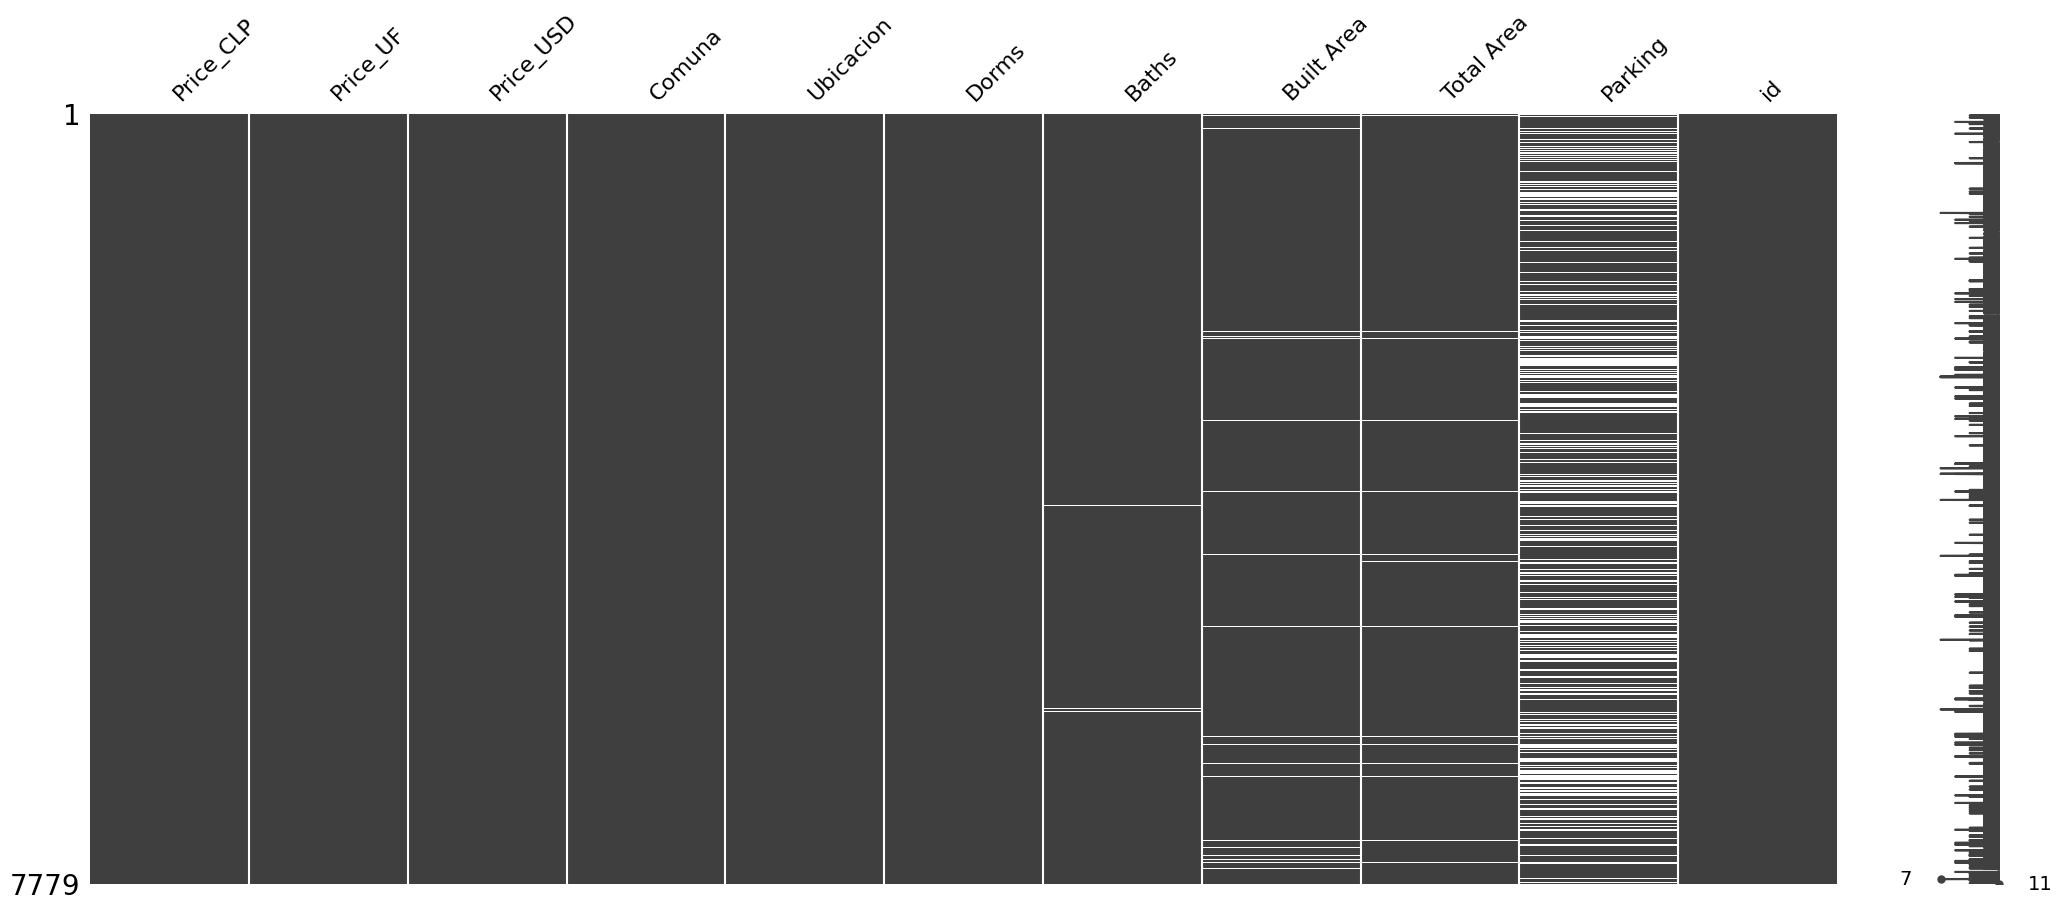

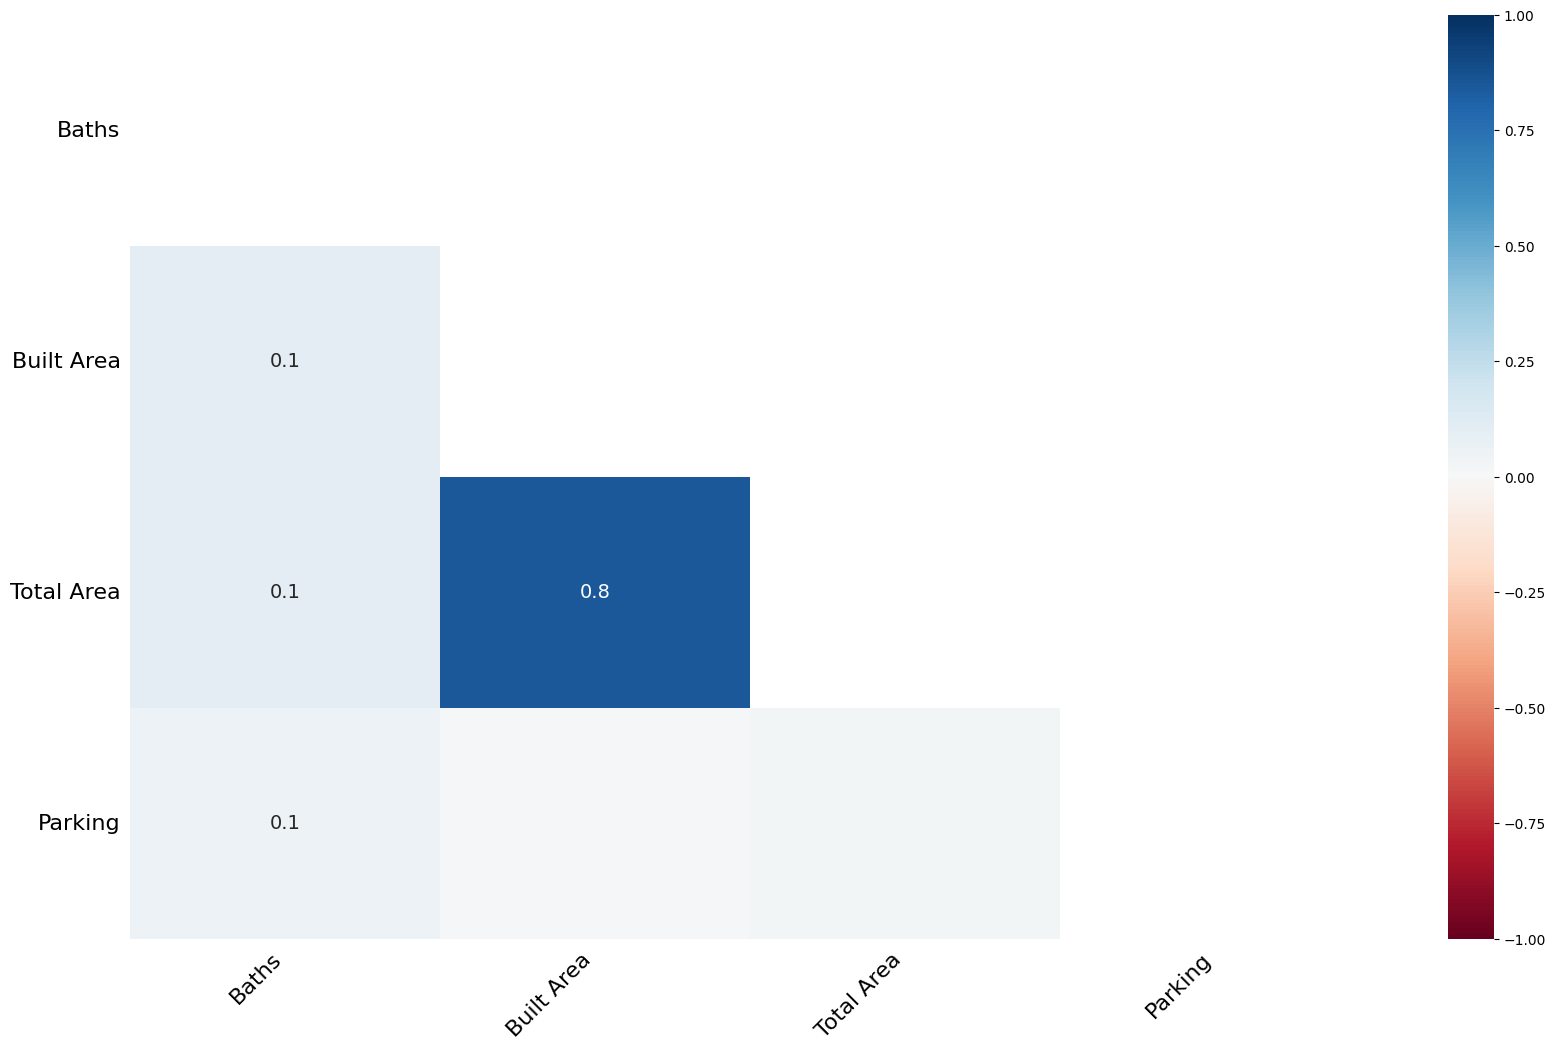

In [5]:
#   Revision
profile_dataframe(df)

Responda las siguientes preguntas (0.2 pts c/u):

1. ¿Cuál es la distribución de la variable objetivo `Price_CLP` en cuanto a tipo de distribución y rangos?
2. Analice las variables categóricas según qué tan útiles son para modelos de machine learning. ¿Qué columnas utilizaría como features y por qué?
3. Para cada variable con nulos, mencione si son nulos porque el dato **no está disponible**, **no aplica** o si realmente **representan un valor determinado**. Pista: considere los rangos observados de cada variable y analice si tiene sentido con el significado de estas presente en la [documentación](.\documentacion_dataset.md).
4. ¿Debería utilizar la columna `id` como feature para entrenar el modelo? ¿Por qué?
5. ¿Se observan valores atípicos? ¿Cuales son?

`1. Del reporte, se identifica un Skew (mayor que cero), lo que indica que  la distribución presenta una cola derecha pronunciada: la mayoría de las observaciones se concentran en valores bajos, pero existen propiedades de precio muy elevado que sesgan la media hacia arriba. Esto lo confirma los quartiles, donde la mitad de las observaciones tienen cifras igual o menores a CLP 205.000.000.Por otro lado, que el valor de la Kurtosis sea 14 revela una distribución con colas muy pesadas y presencia de valores extremos. Del reporte, el promedio de los precios es CLP 100M mayor que la mediana, con una desviación estándar elevada CLP 387M. Este último se debe a la presencia de outliers, siendo el mayor de todos una propiedad de CLP 5.516M.`

`2. Las variables categóricas útiles para modelos de Machine Learning son las que tienen la capacidad capturar patrones complejos y que no tengan alta cardinalidad para no caer en la "Maldición de Dimensionalidad" durante el proceso de encoding. Para nuestro caso, se tienen las variables Comuna y Ubicación, con  cardinalidad de 51 y 6620 respectivamente. Si bien ambas entregan información clave del comportamiento de la variable objetivo, la que nos evitará caer en riesgo de sobreajuste va ser Comuna por su cantidad considerablemente menor de features que no supera la cantidad de observaciones. `

`3. Se identifican las variables con nulos Baths, Built Area, Total Area, Total Area y Parking. En detalle:`
- `Baths representa la cantidad de baños de la casa. Al observar su rango de valores, no tiene casa con "0 baños". Dado que tener al menos un baño es esencial para una vivienda, es válido suponer que la existencia de valores nulos corresponde a que no está disponible esa información para ciertas viviendas.`

- `Built Area representa la cantidad de metros cuadrados construidos que tiene la casa. Esta variable no tiene ceros, pero tiene un valor muy pequeño (1m2) y uno muy elevado (120.000 m2). Esto nos indica que es una variable que puede sufrir de errores de tipeo o que no se conocen con precisión. Dado esto, sus nulos corresponde a un dato "no disponible", pues no tiene sentido el "no aplica" si la propiedad ya está construida.`

- `Total Area representa la cantidad de metros cuadrados toda la propiedad. Sigue la misma lógica de la varible Built Area, por lo que sus nulos representan "no disponible"`

- `Parking representa la cantidad de estacionamientos que tiene la casa. Esta variable tiene la particularidad de tener un porcentaje considerable de valores nulos. Por la naturaleza de la variable, puede que para las viviendas que no tienen estacionamiento no registran la cantidad 0 para indicar que no tienen estacionamiento, sino que las dejan en blanco. Por lo que, para esta variable sus nulos representan tanto un valor determinado de tener 0 estacionamientos o que sea un caso de "no aplica" para este feature.`

`4. No se debe utilizar la columna ID porque la naturaleza de ser único para cada observación no entrega información predictora y que puede hacer que el modelo entrenado pierda su capacidad de generalización ante nuevos datos `

`5. Hay valores atípicos para todas las variables numéricas. En la variable objetivo, se tiene como valor máximo una vivienda a CLP 5.516 M, USD 6.000M. En Dorms una vivienda tiene 27 dormitorios, en Baths 29 baños, Built Area 120.000 m2, Total Area 678.000 m2 y en Parking 1269 estacionamientos`

`Como extra, Built Area y Total Area están altamente correlacionadas, por lo que solo utilizaremos para ajustar el modelo la variable Built Area debido que si incluimos las dos, nos causará inestabilidad en los coeficientes`

### 1.2 Preparación de datos [0.75 ptos]

Cree la función `preparacion_de_datos` la cual debe realizar toda la carga y preparación inicial de los datos que no corresponde ir en el pipeline de preprocesamiento. En esta función, ud. deberá:
- Cargar el dataset `"Precios Casas RM.csv"`
- Eliminar duplicados usando las columnas que estime conveniente
- Eliminar filas nulas, sólo considerando las columnas que su EDA reveló que corresponde eliminar nulos en esas columnas (para algunas puede tener más sentido imputarlas)
- Eliminar valores atípicos (Opcional). Puede aplicar criterio personal a lo que considera atípico.
- Separación del target
- Holdout

Ejecute esta función para obtener ``X_train``, ``X_test``, ``y_train``, ``y_test`` (0.5 ptos)

Luego, justifique su preparación de datos al final de la sección (0.25 ptos)

In [6]:
def preparacion_de_datos():
    df = pd.read_csv("Precios Casas RM.csv")  # noqa: F841

    # eliminar duplicados y hacer copia
    df_limpio = df.drop_duplicates(keep="first").copy()  # conserva una y elimina el resto de copias

    # eliminar filas nulas de Baths pues sus nulos representan el 0.84 % del dataset. Para las otras, se imputará
    df_limpio = df_limpio.dropna(axis=0, subset=["Baths"])

    ## eliminacion de outliers por metodo IQR
    # seleccion de variables numericas que no sean ID
    col_numericas = df_limpio.drop(columns=["Ubicacion", "Comuna", "id"]).columns.tolist()

    # eliminación de los outliers
    for col in col_numericas:
        Q1 = df_limpio[col].quantile(0.25)
        Q3 = df_limpio[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Filtrar manteniendo los valores en rango y los nulos
        df_limpio = df_limpio[
            (df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior) | (df_limpio[col].isna())
        ]

    # separación del target
    X = df_limpio.drop(columns=["Price_CLP", "Price_USD", "Price_UF", "Ubicacion", "Total Area", "id"])
    y = df_limpio["Price_CLP"]

    # holdout
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, shuffle=True, test_size=0.3, random_state=7202
    )  # 70-30 es un buen inicio

    return X_train, X_test, y_train, y_test

In [7]:
X_train, X_test, y_train, y_test = preparacion_de_datos()

In [8]:
# Ver la cantidad de filas quedaron tras limpieza
print(" Resumen de Partición de Datos")
print(f"Total de filas en Entrenamiento (X_train): {X_train.shape[0]}")
print(f"Total de filas en Prueba (X_test):        {X_test.shape[0]}")

# verificr si coinciden con respecto a X
print(f"\nTotal de etiquetas en Train (y_train):    {y_train.shape[0]}")
print(f"Total de etiquetas en Test (y_test):       {y_test.shape[0]}")

# Checar si cumple con la proporcion
total_filas = X_train.shape[0] + X_test.shape[0]
print(f"\nProporción: {X_train.shape[0] / total_filas:.0%} Train / {X_test.shape[0] / total_filas:.0%} Test")

 Resumen de Partición de Datos
Total de filas en Entrenamiento (X_train): 3635
Total de filas en Prueba (X_test):        1559

Total de etiquetas en Train (y_train):    3635
Total de etiquetas en Test (y_test):       1559

Proporción: 70% Train / 30% Test


Justificar su preparación de datos.
- ¿Qué columnas usó para eliminar nulos y por qué? 
> Respuesta: optamos por eliminar las filas con nulos en `Baths` pues solo representaban el 0.84% del dataset, una cantidad pequeña que no impacta su eliminación en el rendimiento de la estimación. Con respecto a las otras columnas con nulos, optamos por imputarlas más adelante pues representaban el 3% (total area) y 30% (Parking) del dataset.
- ¿Qué proporción de los datos usó para test y por qué?  
> Respuesta: Utilizamos la proporción 70% para entrenamiento y 30% para testeo para garantizar que el modelo disponga de una base de conocimiento lo suficientemente amplia para capturar la variabilidad del dataset pues este se redujo de 7799 observaciones a 5194 tras la limpieza, manteniendo al mismo tiempo un conjunto de validación significativo que asegura la confiabilidad y generalización.

### 1.3 Preprocesamiento [1 ptos]

Confeccione un `ColumnTransformer` que realice el preprocesamiento de los datos (0.75 ptos). Se recomienda fuertemente basarse en sus observaciones del EDA. El column transformer deberá realizar: 
- Selección de columnas
- Imputación de valores nulos, si los hay
- Escalamiento de variables numéricas
- Encoding de variables categóricas con `one hot encoding`.
- No eliminar la variable `Comuna`

Luego, debe responder las preguntas al final de la sección donde se pide justificar su preprocesamiento. (0.25 ptos)

In [9]:
from sklearn.compose import ColumnTransformer  # noqa: I001
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [10]:
# definir primero los pipelines para las dos imputaciones
numericas_transformer = Pipeline([("Imputación", SimpleImputer(strategy="median")), ("Escalado", StandardScaler())])

parking_transformer = Pipeline(
    [("Imputacion", SimpleImputer(strategy="constant", fill_value=0)), ("Escalado", StandardScaler())]
)

preprocesamiento = ColumnTransformer(
    [
        ("numericos", numericas_transformer, ["Built Area"]),
        ("parking", parking_transformer, ["Parking"]),
        ("categoricas", OneHotEncoder(), ["Comuna"]),
    ]
)

Justificar su preprocesamiento.
- ¿Qué columnas eliminó y por qué?
- ¿Por qué escaló los features de esta forma?
- ¿Qué valor(es) usó para imputación y por qué?

`1. Se eliminaron las variables 'Price_USD', 'Price_UF', 'Ubicacion', 'Total Area' e 'id' por las siguientes razones: Price_USD y Price_UF: al ser conversiones aritméticas de la variable objetivo, presentan correlación perfecta con 'Price_CLP', lo que introduce multicolinealidad perfecta en el modelo; Ubicacion: su cardinalidad supera el número de observaciones, imposibilitando que el modelo extraiga patrones generalizables, por lo que se prefiere 'Comuna' como alternativa, ya que agrupa las observaciones en categorías manejables evitando la maldición de la dimensionalidad; Total Area: presenta alta correlación con 'Built Area', por lo que ambas capturan información similar y mantener las dos introduciría multicolinealidad; id: es un identificador aleatorio sin poder predictivo, cuya inclusión podría provocar memorización de los datos de entrenamiento y deteriorar la capacidad de generalización del modelo.`

`2. Se aplicó StandardScaler para estandarizar las variables predictoras, así aseguramos que atributos con magnitudes mayores como 'Built Area' no dominen sobre variables de menor escala como 'Baths' o 'Parking'. Se optó por este escalador dado que, al haber eliminado previamente los outliers, la media y desviación estándar son representativas de la tendencia central del dataset y por lo tanto adecuadas para el escalamiento.`


`3. Se realizaron dos imputaciones para Built Area y Parking. Para Built Area optamos imputar con la mediana pues por la asimetría de sus datos, este estadístico es el que mejor representa a la casa típica del dataset. Por otro lado, para Parking se optó imputar por 0, dado que, se determinó que lo nulos de esta columna significan falta de estacionamiento y no un dato perdido al azar.`

### 1.4 Entrenamiento de modelo [0.25 ptos]

A continuación debe crear el `Pipeline` final que incluye el preprocesamiento y el modelo. Para esto usted debe:
- Elegir uno de los modelos vistos en clase: `Regresión lineal`, `Ridge`, `LASSO`, `ElasticNet`
- Crear un pipeline que incluya el preprocesamiento obtenido en la sección anterior y el modelo elegido con hiperparámetros a su elección
- Entrenar pipeline en el dataset de entrenamiento

In [11]:
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge  # noqa: F401

pipeline = Pipeline([("preprocesamiento", preprocesamiento), ("regresor", LinearRegression())])
# entrenamiento
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('regresor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericos', ...), ('parking', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

### 1.5 Evaluación [1 ptos]

Finalmente llegó el momento de evaluar la capacidad predictiva de su modelo **en datos de test** y demostrarle a don Elias que su trabajo agrega valor a _Tasai_. Para esto, usted deberá:
1. Crear la función `evaluate_model` que reciba el pipeline y los datos de test, realice predicciones y luego calcule las métricas **RMSE**, **MAE** (mean absolute error) y **$R^2$** tanto en datos de **train** como datos de **test**, diferenciándolos mediante prints. (0.2 ptos)

In [12]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score  # noqa: I001


def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    # predicciones
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # evaluación en conjunto entrenamiento
    print("--- Métricas: Conjunto de Entrenamiento ---")
    print("RMSE", root_mean_squared_error(y_train, y_train_pred))
    print("MAE", mean_absolute_error(y_train, y_train_pred))
    print("R2", r2_score(y_train, y_train_pred))

    # evaluación en conjunto prueba
    print("--- Métricas: Conjunto de Prueba ---")
    print("RMSE", root_mean_squared_error(y_test, y_test_pred))
    print("MAE", mean_absolute_error(y_test, y_test_pred))
    print("R2", r2_score(y_test, y_test_pred))

2. Crear la función `complete_pipeline_v1` que utilice las funciones y objetos definidos anteriorment (`preparacion_de_datos`, el pipeline y `evaluate_model`) de forma que al ejecutarlo se obtengan las métricas del modelo (0.2 ptos)

In [13]:
def complete_pipeline_v1(pipe):
    # obtener conjunto de entrenamiento y prueba
    X_train, X_test, y_train, y_test = preparacion_de_datos()

    # preprocesamiento y entrenamiento
    pipe.fit(X_train, y_train)

    # evaluación del modelo
    evaluate_model(pipe, X_train, X_test, y_train, y_test)


# llamamos a pipeline
complete_pipeline_v1(pipeline)

--- Métricas: Conjunto de Entrenamiento ---
RMSE 75526483.48685722
MAE 53441163.57228673
R2 0.7566238469108484
--- Métricas: Conjunto de Prueba ---
RMSE 75430611.9009088
MAE 52468921.092469595
R2 0.7681047753717026


3. Responder las siguientes preguntas (0.15 ptos c/u)
- ¿Qué tan bien el modelo predice el precio de la vivienda? Justifique su respuesta basándose en las 3 métricas obtenidas (debe decir algo de cada métrica)
> El modelo tiene un desempeño robusto, capaz de explicar el 76,8% de la variabilidad de los precios CLP de las viviendas. Tiene ambos errores elevados, con RMSE siendo mayor que MAE en ambos conjuntos de entrenamiento y prueba, lo que nos indica que el modelo tiene dificultades para estimar correctamente las viviendas muy caras o baratas.
- ¿Qué diferencia haría elegir un modelo que optimice cada una de las 3 métricas?
> Si se optimiza R2, buscará un modelo que captura la tendencia general del mercado, por lo que le interesaría ver que variables mueven el precio globalmente. Si se decide por optimizar MAE, produciría un modelo que minimizaría el error promedio. Y si se optimiza el RMSE, entregaría un modelo minimizando lo más posible el error, ideal cuando se quiere evitar el costo elevado de una predicción.  
- ¿Qué factores pueden haber influido en el desempeño del modelo? Discuta posibles fuentes de error
> Puede deberse a que faltan variables en el dataset que expliquen el precio como la cercanía a un metro, antiguedad, entre otros. Otra fuente de error podría ser que estamos asumiendo que el precio crece de forma lineal cuando en la practica suele ser no lineal.         
- Compare las métricas obtenidas con datos de entrenamiento y test. ¿Hubo sobreajuste? Justifique
> Ambos métricas entre entrenamiento y prueba tienen valores similares sin fuertes variaciones. Esto nos dice que el modelo tiene capacidad de generalizar ante presencia de nuevos datos, porque si hubiese sufrido sobreajuste, la métrica R2 train sería casi perfecta mientras que R2 test tendría una caída fuerte.

## 2. Análisis de sobreajuste

Don Elias está contento con sus resultados... pero no tanto. Él piensa que el modelo puede mejorar aún más, por lo que ha decidido contactar a **consultores externos** de la empresa _SuperAI_ para complementar su equipo de trabajo. Los consultores de _SuperAI_ le comentan que consideran que el tratamiento de datos ha sido **subóptimo** debido principalmente a que produce **sobreajuste** y que creen que pueden mejorar el modelo incluyendo datos adicionales sobre las **características socioeconómicas** de las comunas para mitigar el sobreajuste.

### 2.1 Incorporación de datos adicionales [0.5 ptos]

Los consultores de _SuperAI_ le han proporcionado un dataset adicional presente en el archivo `ingresos_por_comuna_2024.xlsx`, el cual contiene la población y el porcentaje de personas en situación de pobreza por comuna. Le encargan **cruzar** estos datos con el dataset principal para incorporar esta información del porcentaje de pobreza en la predicción.

Para esto, usted deberá crear la función `preparacion_de_datos_2`, la cual es una copia de `preparacion_de_datos` pero que incluye la carga del dataset `ingresos_por_comuna_2024.xlsx` y merge con `Precios Casas RM.csv`. Considerar:
- Sólo incorporar la columna `Porcentaje de personas en situacion de pobreza de ingresos 2024` en el dataset
- Renombrar la columna a un nombre más corto
- No modificar nada más de la función original `preparacion_de_datos`

In [41]:
def preparacion_de_datos_2():
    df = pd.read_csv("Precios Casas RM.csv")  # noqa: F841
    df_comunas = pd.read_excel("ingresos_por_comuna_2024.xlsx")  # noqa: F841

    # Renombrar columna comuna y Porcentaje de personas en situacion de pobreza de ingresos 2024
    df_comunas.rename(
        columns={
            "Nombre comuna": "Comuna",
            "Porcentaje de personas en situacion de pobreza de ingresos 2024": "pct_pobreza_ingresos",
        },
        inplace=True,
    )

    # Se selecciona solo fila comuna y pct_pobreza_ingresos
    df_comunas_filtred = df_comunas[["Comuna", "pct_pobreza_ingresos"]]

    # Se realiza un merge usando comuna como variable común
    df_merged = pd.merge(df, df_comunas_filtred, on="Comuna")

    # eliminar duplicados y hacer copia
    df_limpio = df_merged.drop_duplicates(keep="first").copy()  # conserva una y elimina el resto de copias

    # eliminar filas nulas de Baths pues sus nulos representan el 0.84 % del dataset. Para las otras, se imputará
    df_limpio = df_limpio.dropna(axis=0, subset=["Baths"])

    ## eliminacion de outliers por metodo IQR
    # seleccion de variables numericas que no sean ID o númericas
    col_numericas = df_limpio.drop(columns=["Ubicacion", "Comuna", "id", "pct_pobreza_ingresos"]).columns.tolist()

    # eliminación de los outliers
    for col in col_numericas:
        Q1 = df_limpio[col].quantile(0.25)
        Q3 = df_limpio[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Filtrar manteniendo los valores en rango y los nulos
        df_limpio = df_limpio[
            (df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior) | (df_limpio[col].isna())
        ]

    # separación del target
    X = df_limpio.drop(columns=["Price_CLP", "Price_USD", "Price_UF", "Ubicacion", "Total Area", "id"])
    y = df_limpio["Price_CLP"]

    # holdout
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, shuffle=True, test_size=0.3, random_state=7202
    )  # 70-30 es un buen inicio

    return X_train, X_test, y_train, y_test

In [42]:
X_train2, X_test2, y_train2, y_test2 = preparacion_de_datos_2()

In [43]:
# Ver la cantidad de filas quedaron tras limpieza
print(" Resumen de Partición de Datos")
print(f"Total de filas en Entrenamiento (X_train): {X_train2.shape[0]}")
print(f"Total de filas en Prueba (X_test):        {X_test2.shape[0]}")

# verificr si coinciden con respecto a X
print(f"\nTotal de etiquetas en Train (y_train):    {y_train2.shape[0]}")
print(f"Total de etiquetas en Test (y_test):       {y_test2.shape[0]}")

# Checar si cumple con la proporcion
total_filas = X_train2.shape[0] + X_test2.shape[0]
print(f"\nProporción: {X_train2.shape[0] / total_filas:.0%} Train / {X_test2.shape[0] / total_filas:.0%} Test")

 Resumen de Partición de Datos
Total de filas en Entrenamiento (X_train): 3635
Total de filas en Prueba (X_test):        1559

Total de etiquetas en Train (y_train):    3635
Total de etiquetas en Test (y_test):       1559

Proporción: 70% Train / 30% Test


### 2.2 Adaptación del pipeline [0.5 ptos]

Como su función de carga de datos incorpora una nueva columna, se ve obligado a adaptar el resto del pipeline. Adicionalmente, los consultores de _SuperAI_ creen que el modelo todavía puede mejorar, por lo que le solicitan utilizar un procesamiento distinto de la columna `Comuna`. Esta vez, en vez de utilizar **One hot encoding** en la variable **comuna** (o de eliminar la columna si hizo esto), deberá utilizar **Target encoding**. El target encoding es una técnica de feature engineering para procesas variables categóricas donde la variable categórica se remplaza por el promedio de la variable objetivo. Es decir, en este caso se remplaza la comuna por el valor promedio de las propiedades de esa comuna.

Su objetivo en esta sección es crear la función `complete_pipeline_v2` de igual manera que la sección anterior, con las siguientes modificaciones:
- Incluir la nueva variable dentro de las columnas del preprocesamiento numérico
- Utilizar `TargetEncoder(target_type='continuous')` para procesar la variable categórica **comuna**
- Crear la función `complete_pipeline_v2` usando `preparacion_de_datos_2`, el nuevo pipeline y `evaluate_model` (no debería necesitar modificaciones)


In [47]:
from sklearn.preprocessing import TargetEncoder  # noqa: F401

preprocesamiento2 = ColumnTransformer(
    [
        ("numericos", numericas_transformer, ["Built Area", "pct_pobreza_ingresos"]),
        ("parking", parking_transformer, ["Parking"]),
        ("categoricas", TargetEncoder(target_type="continuous"), ["Comuna"]),
    ]
)

pipeline2 = Pipeline([("preprocesamiento", preprocesamiento2), ("regresor", LinearRegression())])

In [48]:
def complete_pipeline_v2(pipe):
    # obtener conjunto de entrenamiento y prueba
    X_train, X_test, y_train, y_test = preparacion_de_datos_2()

    # preprocesamiento y entrenamiento
    pipe.fit(X_train, y_train)

    # evaluación del modelo
    evaluate_model(pipe, X_train, X_test, y_train, y_test)

### 2.3 Comparación de resultados [0.5 ptos]

Finalmente, habiendo construido 2 pipelines diferentes para abordar el mismo problema, don Elias está ansioso por ver los resultados.

- Ejecutar `complete_pipeline_v1` y `complete_pipeline_v2`
- Comparar las métricas y comentar los resultados. ¿Qué modelo considera que le fue mejor?

In [68]:
# llamamos a pipeline
print("-----------------------------------------------\n Resultados Pipeline V1: \n")
complete_pipeline_v1(pipeline)

print("-----------------------------------------------\n Resultados Pipeline V2")
complete_pipeline_v2(pipeline2)

-----------------------------------------------
 Resultados Pipeline V1: 

--- Métricas: Conjunto de Entrenamiento ---
RMSE 75526483.48685722
MAE 53441163.57228673
R2 0.7566238469108484
--- Métricas: Conjunto de Prueba ---
RMSE 75430611.9009088
MAE 52468921.092469595
R2 0.7681047753717026
-----------------------------------------------
 Resultados Pipeline V2
--- Métricas: Conjunto de Entrenamiento ---
RMSE 76613662.68526429
MAE 54798341.14107315
R2 0.7495667763998337
--- Métricas: Conjunto de Prueba ---
RMSE 75883705.2846035
MAE 53070862.77289652
R2 0.7653105316314348


`Ambos modelos obtuvieron un rendimiento similar, con diferencias marginales entre sí. Sin embargo, el modelo V1 presenta mejores métricas en el conjunto de prueba: menor RMSE, menor MAE y mayor R², lo que indica que generaliza levemente mejor a datos no vistos.`

### 2.4 Discusión [0.5 ptos]

1. Considerando los resultados obtenidos mencione al menos 2 razones de por qué cree que a uno de los modelos le fue mejor que a otro. ¿Cómo se relaciona con el fenómeno de sobreajuste?

`Una primera razón es que la variable `pct_pobreza_ingresos` toma un valor constante para todas las propiedades de una misma comuna, lo que la hace redundante respecto a `Comuna` e introduce multicolinealidad. Al no agregar variabilidad nueva entre observaciones de la misma comuna, su aporte predictivo es limitado y puede interferir con la estimación de los coeficientes del modelo. Una segunda razón es que el Target Encoding reemplaza cada comuna por el promedio del precio de sus propiedades, calculado sobre el conjunto de entrenamiento, lo que puede introducir data leakage o estimaciones ruidosas en comunas con pocas observaciones, perjudicando la capacidad de generalización del modelo respecto al One Hot Encoding`

`Respecto al sobreajuste, en ambos modelos las métricas de entrenamiento y prueba son muy similares, lo que indica ausencia de overfitting en los dos casos. Esto era esperable dado que se aplicó eliminación de outliers y estandarización previamente, lo que reduce la varianza del modelo.`

2. Determine la cantidad de parámetros (complejidad) de los 2 modelos entrenados usando `pipeline.steps[...]` para obtener el modelo y luego imprimiendo el largo del atributo `coef_`. Luego, considerando las métricas de ambos modelos y la complejidad ¿Qué puede decir sobre el tratamiento de datos del segundo pipeline? Justifique

In [67]:
# Pipeline V1
coef_v1 = pipeline.steps[-1][1].coef_
largoV1 = len(coef_v1)
print(f"Pipeline V1 - Cantidad de parámetros: {largoV1}")

# Pipeline V2
coef_v2 = pipeline2.steps[-1][1].coef_
largoV2 = len(coef_v2)
print(f"Pipeline V2 - Cantidad de parámetros: {largoV2}")

Pipeline V1 - Cantidad de parámetros: 52
Pipeline V2 - Cantidad de parámetros: 4


`Se puede observar que V1 usa 13 veces más parámetros que V2, lo que se explica porque V1 aplica One Hot Encoding sobre Comuna, generando una columna binaria por cada comuna distinta y resultando en alta dimensionalidad. En cambio, V2 usa Target Encoding, que reemplaza la variable categórica por una sola columna numérica, reduciendo drásticamente la complejidad del modelo. A pesar de esta gran diferencia en complejidad, ambos modelos obtuvieron métricas muy similares, lo que sugiere que el tratamiento de datos de V2 es más eficiente. Sin embargo, la reducción de parámetros puede ser una limitante, pues el modelo V2 estaría perdiendo la capacidad de capturar diferencias específicas entre comunas que el One Hot Encoding sí preserva.`